# Problem 4: Laminar/turbulent flow above a suddenly moved plate
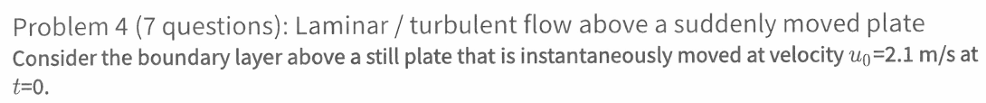

In [2]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from scipy.special import erfc, erfcinv
from scipy.integrate import solve_ivp

In [3]:
u_0 = 2.1                   # Plate velocity amplitude [m/s]
viscosity = 1.3*10**-6      # Kinematic viscosity [m2/s]
rho_water = 1000            # density of water (kg/m^3)
kappa = 0.4                 # von Karman constant

### Question 4.1
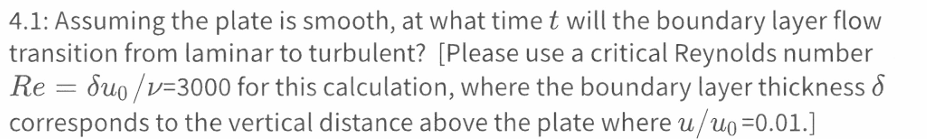
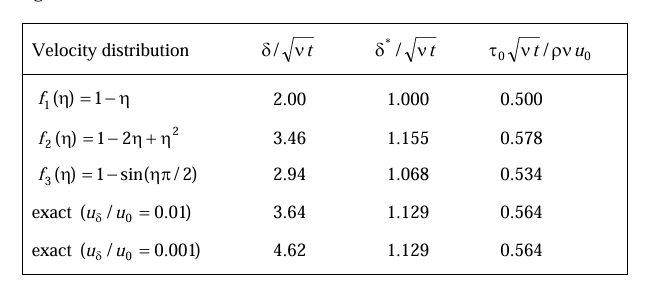
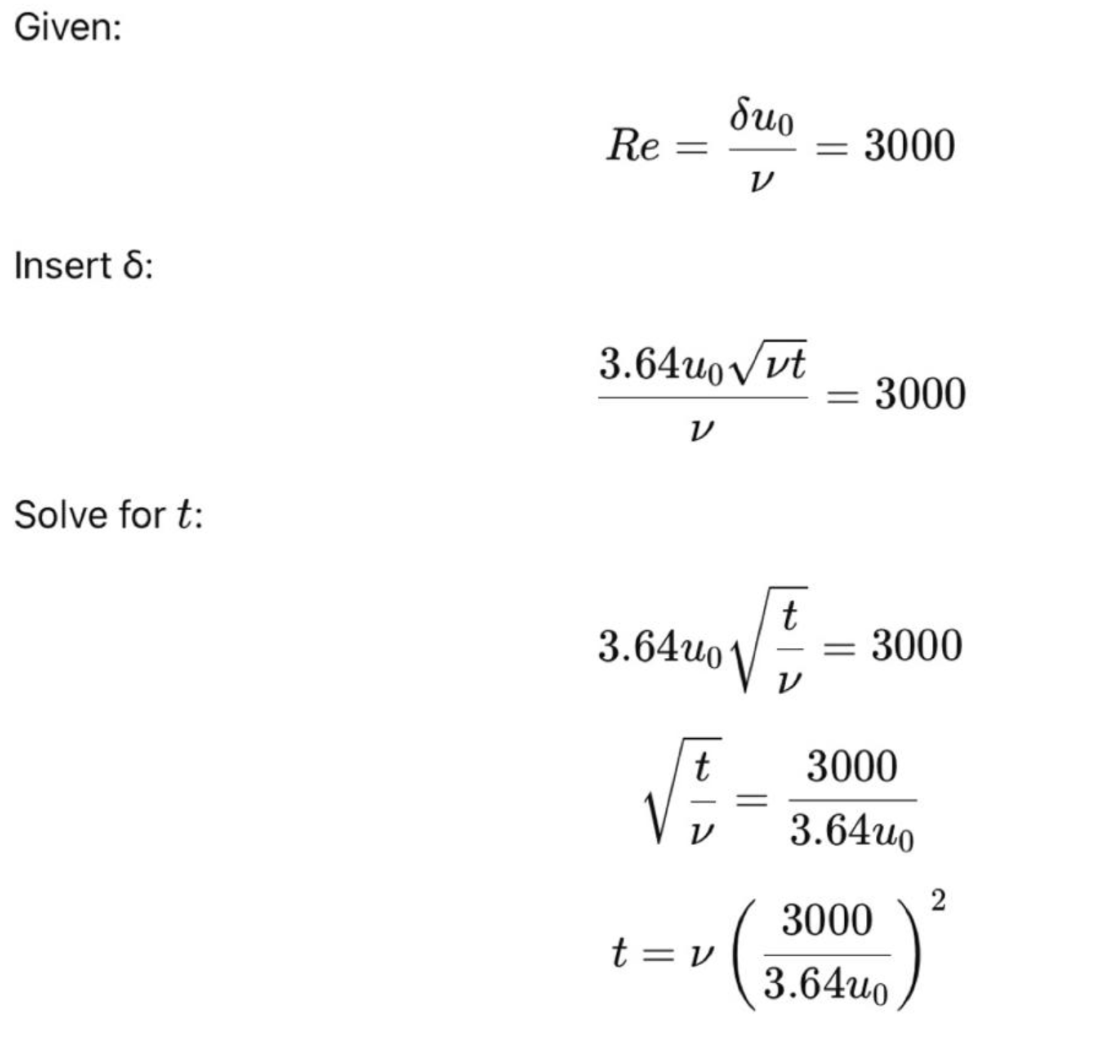

In [4]:
# Critical Reynolds number for transition
Re_crit = 3000.0          

# δ from critical Reynolds number -> Re = delta * u_0 / viscosity
delta = Re_crit * viscosity / u_0   # m

# Formula for the exact solution of the suddenly-moved-plate problem u/u0 = erfc(y / (2 * sqrt(viscosity * t)))
# η solves erfc(η) = 0.01 because u/u0 = erfc(η) and we use u/u0 = 0.01 at y = δ
y = erfcinv(0.01)

# solve for t: δ = 2 * η * sqrt(nu * t)  =>  t = (δ / (2 η))^2 / nu
t_transition = (delta / (2.0 * y))**2 / viscosity



print(f"Transition time t = {t_transition:.2f} s")



Transition time t = 0.20 s


In [5]:
C = 3.64                 # eq 5.34 

#plate smooth
Re_crit = 3000 #Re = delta * u0 / nu
u = u_0 * 0.01
#boundary layer thickness y=delta


# Solve: Re = (delta * u0) / nu = 3000
# delta = C * sqrt(nu * t)
# => (C * sqrt(nu * t) * u0) / nu = 3000

t_trans = (Re_crit * viscosity / (C * u_0))**2 / viscosity

print("Transition time =", t_trans, "s")

Transition time = 0.20023708070355295 s


### Question 4.2
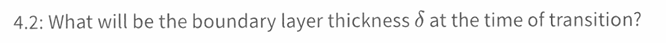

In [6]:
print(f"delta = {delta:.5f} m")
#print(f"y = {y:.6f}")

delta = 0.00186 m


### Question 4.3
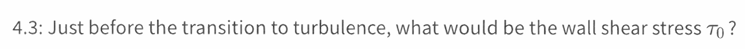

In [7]:
shear_stress = rho_water * -(1/np.sqrt(np.pi)) * ((viscosity * u_0) / np.sqrt(viscosity * t_transition))

print(f"Shear stress at the plate τ = {shear_stress:.2f} Pa")

Shear stress at the plate τ = -3.02 Pa


### Question 4.4
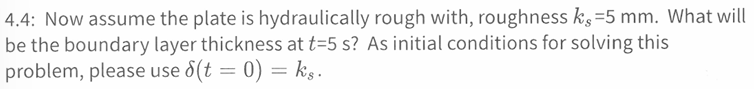
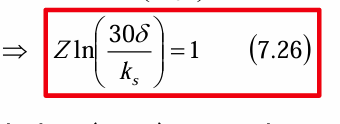
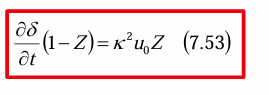

In [8]:
# problem data
k_s = 5e-3        # roughness [m]
t_final = 5.0     # seconds
y0 = k_s / 30.0   # reference in log (from slides)

def Z_from_delta(delta, k_s = k_s):
    # safe evaluation of Z = 1 / ln(30*delta/ks)
    arg = 30.0 * delta / k_s
    if arg <= 1.0:
        arg = 1.0 + 1e-12
    lnterm = np.log(arg)
    Z = 1.0 / lnterm
    # avoid Z -> 1 singularity
    return min(Z, 0.99)

def ddelta_dt(t, y):
    delta = float(y[0])
    Z = Z_from_delta(delta)
    denom = 1.0 - Z
    if abs(denom) < 1e-12:
        return [0.0]
    return [(kappa**2 * u_0 * Z) / denom]

# integrate ODE with δ(0)=k_s
sol = solve_ivp(fun=ddelta_dt, t_span=(0.0, t_final), y0=[k_s],
                rtol=1e-6, atol=1e-9)
delta_5 = sol.y[0, -1]


print(f"δ(0) = {k_s*1000:.2f} mm")
print(f"δ({t_final:.1f} s) = {delta_5:.6f} m = {delta_5:.3f} m")


δ(0) = 5.00 mm
δ(5.0 s) = 0.305894 m = 0.306 m


### Question 4.5
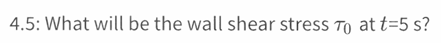

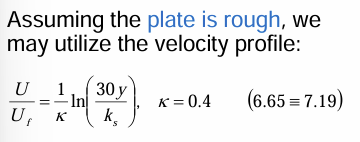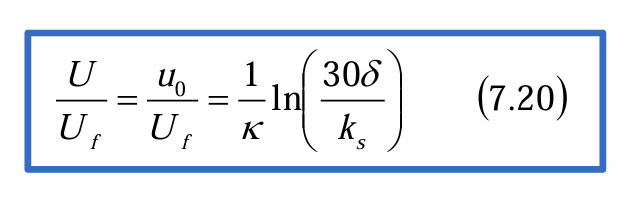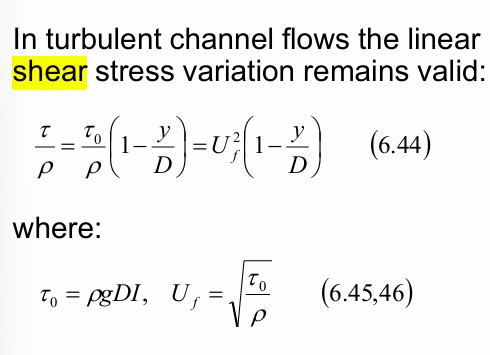

In [14]:
# Wall Shear Stress P10 eq. 6.65 = 7.19 p.7
U_f = u_0/(1/kappa * np.log(30*delta_5/k_s))

tau_wall = -rho_water * U_f**2
print(f"Wall shear stress at t={t_final} s: {tau_wall:.2f} Pa")

Wall shear stress at t=5.0 s: -12.49 Pa


### Question 4.6
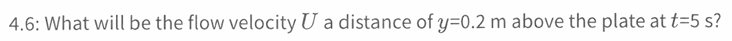

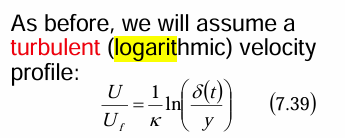
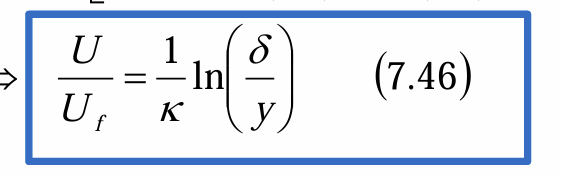

In [10]:
# Wall Shear Stress P10 eq. 6.65 = 7.19 p.7 (the same equation just using the U/U_f instead of u_0/U_f)
y1 = 0.2  # m

def velocity_profile(delta, y):
    if y < k_s/30.0:
        return u_0             # near-bed matching (Roughness region → velocity matches u0 )
    elif y > delta:
        return 0.0            # outside BL (Undisturbed fluid (U=0))
    else:
        return (U_f / kappa) * np.log(delta / y) # Log-law turbulent region

print(f"Velocity at y={y1} m and t={t_final} s (shifted log): {velocity_profile(delta_5, y1):.3f} m/s")

Velocity at y=0.2 m and t=5.0 s (shifted log): 0.119 m/s


### Question 4.7
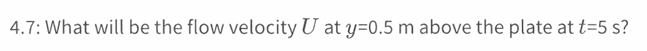

In [11]:
y2 = 0.5 # m

print(f"Velocity at y={y2} m and t={t_final} s (shifted log): {velocity_profile(delta_5, y2):.3f} m/s")

Velocity at y=0.5 m and t=5.0 s (shifted log): 0.000 m/s
